## 准备数据

In [8]:
import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, optimizers, datasets

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # or any {'0', '1', '2'}

def mnist_dataset():
    (x, y), (x_test, y_test) = datasets.mnist.load_data()
    #normalize
    x = x/255.0
    x_test = x_test/255.0
    
    return (x, y), (x_test, y_test)

## Demo numpy based auto differentiation

In [1]:
import numpy as np

class Matmul:
    def __init__(self):
        self.mem = {}
        
    def forward(self, x, W):
        h = np.matmul(x, W)
        self.mem={'x': x, 'W':W}
        return h
    
    def backward(self, grad_y):
        '''
        x: shape(N, d)
        w: shape(d, d')
        grad_y: shape(N, d')
        '''
        x = self.mem['x']
        W = self.mem['W']
        
        ####################
        '''计算矩阵乘法的对应的梯度'''
        grad_x = np.matmul(grad_y, W.T)
        grad_W = np.matmul(x.T, grad_y)
        ####################
        return grad_x, grad_W


class Relu:
    def __init__(self):
        self.mem = {}
        
    def forward(self, x):
        self.mem['x']=x
        return np.where(x > 0, x, np.zeros_like(x))
    
    def backward(self, grad_y):
        '''
        grad_y: same shape as x
        '''
        x = self.mem['x']
        ####################
        '''计算relu 激活函数对应的梯度'''
        grad_x = grad_y * (x > 0).astype(x.dtype)
        ####################
        return grad_x
    


class Softmax:
    '''
    softmax over last dimention
    '''
    def __init__(self):
        self.epsilon = 1e-12
        self.mem = {}
        
    def forward(self, x):
        '''
        x: shape(N, c)
        '''
        x_exp = np.exp(x)
        partition = np.sum(x_exp, axis=1, keepdims=True)
        out = x_exp/(partition+self.epsilon)
        
        self.mem['out'] = out
        self.mem['x_exp'] = x_exp
        return out
    
    def backward(self, grad_y):
        '''
        grad_y: same shape as x
        '''
        s = self.mem['out']
        sisj = np.matmul(np.expand_dims(s,axis=2), np.expand_dims(s, axis=1)) # (N, c, c)
        g_y_exp = np.expand_dims(grad_y, axis=1)
        tmp = np.matmul(g_y_exp, sisj) #(N, 1, c)
        tmp = np.squeeze(tmp, axis=1)
        tmp = -tmp+grad_y*s 
        return tmp
    
class Log:
    '''
    softmax over last dimention
    '''
    def __init__(self):
        self.epsilon = 1e-12
        self.mem = {}
        
    def forward(self, x):
        '''
        x: shape(N, c)
        '''
        out = np.log(x+self.epsilon)
        
        self.mem['x'] = x
        return out
    
    def backward(self, grad_y):
        '''
        grad_y: same shape as x
        '''
        x = self.mem['x']
        
        return 1./(x+self.epsilon) * grad_y
    


## Gradient check

In [3]:
# import tensorflow as tf

x = np.random.normal(size=[5, 6])
# W = np.random.normal(size=[6, 4])
# aa = Matmul()
# out = aa.forward(x, W) # shape(5, 4)
# grad = aa.backward(np.ones_like(out))
# print (grad)

# with tf.GradientTape() as tape:
#     x, W = tf.constant(x), tf.constant(W)
#     tape.watch(x)
#     y = tf.matmul(x, W)
#     loss = tf.reduce_sum(y)
#     grads = tape.gradient(loss, x)
#     print (grads)

# import tensorflow as tf

# x = np.random.normal(size=[5, 6])
# aa = Relu()
# out = aa.forward(x) # shape(5, 4)
# grad = aa.backward(np.ones_like(out))
# print (grad)

# with tf.GradientTape() as tape:
#     x= tf.constant(x)
#     tape.watch(x)
#     y = tf.nn.relu(x)
#     loss = tf.reduce_sum(y)
#     grads = tape.gradient(loss, x)
#     print (grads)

# import tensorflow as tf
# x = np.random.normal(size=[5, 6], scale=5.0, loc=1)
# label = np.zeros_like(x)
# label[0, 1]=1.
# label[1, 0]=1
# label[1, 1]=1
# label[2, 3]=1
# label[3, 5]=1
# label[4, 0]=1
# print(label)
# aa = Softmax()
# out = aa.forward(x) # shape(5, 6)
# grad = aa.backward(label)
# print (grad)

# with tf.GradientTape() as tape:
#     x= tf.constant(x)
#     tape.watch(x)
#     y = tf.nn.softmax(x)
#     loss = tf.reduce_sum(y*label)
#     grads = tape.gradient(loss, x)
#     print (grads)

# import tensorflow as tf

# x = np.random.normal(size=[5, 6])
# aa = Log()
# out = aa.forward(x) # shape(5, 4)
# grad = aa.backward(label)
# print (grad)

# with tf.GradientTape() as tape:
#     x= tf.constant(x)
#     tape.watch(x)
#     y = tf.math.log(x)
#     loss = tf.reduce_sum(y*label)
#     grads = tape.gradient(loss, x)
#     print (grads)

# Final Gradient Check

In [4]:
import tensorflow as tf

label = np.zeros_like(x)
label[0, 1]=1.
label[1, 0]=1
label[2, 3]=1
label[3, 5]=1
label[4, 0]=1

x = np.random.normal(size=[5, 6])
W1 = np.random.normal(size=[6, 5])
W2 = np.random.normal(size=[5, 6])

mul_h1 = Matmul()
mul_h2 = Matmul()
relu = Relu()
softmax = Softmax()
log = Log()

h1 = mul_h1.forward(x, W1) # shape(5, 4)
h1_relu = relu.forward(h1)
h2 = mul_h2.forward(h1_relu, W2)
h2_soft = softmax.forward(h2)
h2_log = log.forward(h2_soft)


h2_log_grad = log.backward(label)
h2_soft_grad = softmax.backward(h2_log_grad)
h2_grad, W2_grad = mul_h2.backward(h2_soft_grad)
h1_relu_grad = relu.backward(h2_grad)
h1_grad, W1_grad = mul_h1.backward(h1_relu_grad)

print(h2_log_grad)
print('--'*20)
# print(W2_grad)

with tf.GradientTape() as tape:
    x, W1, W2, label = tf.constant(x), tf.constant(W1), tf.constant(W2), tf.constant(label)
    tape.watch(W1)
    tape.watch(W2)
    h1 = tf.matmul(x, W1)
    h1_relu = tf.nn.relu(h1)
    h2 = tf.matmul(h1_relu, W2)
    prob = tf.nn.softmax(h2)
    log_prob = tf.math.log(prob)
    loss = tf.reduce_sum(label * log_prob)
    grads = tape.gradient(loss, [prob])
    print (grads[0].numpy())

[[  0.           4.95681957   0.           0.           0.
    0.        ]
 [  1.8128317    0.           0.           0.           0.
    0.        ]
 [  0.           0.           0.         100.65191568   0.
    0.        ]
 [  0.           0.           0.           0.           0.
    5.46690681]
 [  9.03792613   0.           0.           0.           0.
    0.        ]]
----------------------------------------
[[  0.           4.95681957   0.           0.           0.
    0.        ]
 [  1.8128317    0.           0.           0.           0.
    0.        ]
 [  0.           0.           0.         100.65191569   0.
    0.        ]
 [  0.           0.           0.           0.           0.
    5.46690681]
 [  9.03792613   0.           0.           0.           0.
    0.        ]]


## 建立模型

In [19]:
class myModel:
    def __init__(self):
        
        self.W1 = np.random.normal(size=[28*28+1, 100])
        self.W2 = np.random.normal(size=[100, 10])
        
        self.mul_h1 = Matmul()
        self.mul_h2 = Matmul()
        self.relu = Relu()
        self.softmax = Softmax()
        self.log = Log()
        
        
    def forward(self, x):
        x = x.reshape(-1, 28*28)
        bias = np.ones(shape=[x.shape[0], 1])
        x = np.concatenate([x, bias], axis=1)
        
        self.h1 = self.mul_h1.forward(x, self.W1) # shape(5, 4)
        self.h1_relu = self.relu.forward(self.h1)
        self.h2 = self.mul_h2.forward(self.h1_relu, self.W2)
        self.h2_soft = self.softmax.forward(self.h2)
        self.h2_log = self.log.forward(self.h2_soft)
            
    def backward(self, label):
        self.h2_log_grad = self.log.backward(-label)
        self.h2_soft_grad = self.softmax.backward(self.h2_log_grad)
        self.h2_grad, self.W2_grad = self.mul_h2.backward(self.h2_soft_grad)
        self.h1_relu_grad = self.relu.backward(self.h2_grad)
        self.h1_grad, self.W1_grad = self.mul_h1.backward(self.h1_relu_grad)
        
model = myModel()


## 计算 loss

In [20]:
def compute_loss(log_prob, labels):
     return np.mean(np.sum(-log_prob*labels, axis=1))
    

def compute_accuracy(log_prob, labels):
    predictions = np.argmax(log_prob, axis=1)
    truth = np.argmax(labels, axis=1)
    return np.mean(predictions==truth)

def train_one_step(model, x, y):
    model.forward(x)
    model.backward(y)
    model.W1 -= 1e-5* model.W1_grad
    model.W2 -= 1e-5* model.W2_grad
    loss = compute_loss(model.h2_log, y)
    accuracy = compute_accuracy(model.h2_log, y)
    return loss, accuracy

def test(model, x, y):
    model.forward(x)
    loss = compute_loss(model.h2_log, y)
    accuracy = compute_accuracy(model.h2_log, y)
    return loss, accuracy

## 实际训练

In [22]:
train_data, test_data = mnist_dataset()
train_label = np.zeros(shape=[train_data[0].shape[0], 10])
test_label = np.zeros(shape=[test_data[0].shape[0], 10])
train_label[np.arange(train_data[0].shape[0]), np.array(train_data[1])] = 1.
test_label[np.arange(test_data[0].shape[0]), np.array(test_data[1])] = 1.

for epoch in range(500):
    loss, accuracy = train_one_step(model, train_data[0], train_label)
    print('epoch', epoch, ': loss', loss, '; accuracy', accuracy)
loss, accuracy = test(model, test_data[0], test_label)

print('test loss', loss, '; accuracy', accuracy)

epoch 0 : loss 7.664555251747255 ; accuracy 0.6903166666666667
epoch 1 : loss 7.630950227149723 ; accuracy 0.6918
epoch 2 : loss 7.596839723889561 ; accuracy 0.69315
epoch 3 : loss 7.572268236505826 ; accuracy 0.6944666666666667
epoch 4 : loss 7.5478950047829265 ; accuracy 0.6955666666666667
epoch 5 : loss 7.542168684662282 ; accuracy 0.6963166666666667
epoch 6 : loss 7.527972813221346 ; accuracy 0.6964833333333333
epoch 7 : loss 7.5525704559595574 ; accuracy 0.6961833333333334
epoch 8 : loss 7.543572004398116 ; accuracy 0.6958833333333333
epoch 9 : loss 7.606848054712009 ; accuracy 0.6939833333333333
epoch 10 : loss 7.6186414434320815 ; accuracy 0.6920666666666667
epoch 11 : loss 7.7370139888656135 ; accuracy 0.6879833333333333
epoch 12 : loss 7.741388252271653 ; accuracy 0.6864833333333333
epoch 13 : loss 7.8516684025876815 ; accuracy 0.6829833333333334
epoch 14 : loss 7.707445946610196 ; accuracy 0.6881166666666667
epoch 15 : loss 7.708658884870134 ; accuracy 0.6896166666666667
epoc

双层Relu网络拟合任意闭合有界函数

In [2]:
class DoubleReluNet:
    def __init__(self, hidden1=64, hidden2=64):
        self.W1 = np.random.normal(scale=0.2, size=(1, hidden1))
        self.b1 = np.zeros((1, hidden1))
        self.W2 = np.random.normal(scale=0.2, size=(hidden1, hidden2))
        self.b2 = np.zeros((1, hidden2))
        self.W3 = np.random.normal(scale=0.2, size=(hidden2, 1))
        self.b3 = np.zeros((1, 1))

        self.matul_h1 = Matmul()
        self.matul_h2 = Matmul()
        self.matul_h3 = Matmul()
        self.relu1 = Relu()
        self.relu2 = Relu()

    def forward(self, x):
        self.x = x.reshape(-1, 1)
        self.z1 = self.matul_h1.forward(self.x, self.W1) + self.b1
        self.a1 = self.relu1.forward(self.z1)
        self.z2 = self.matul_h2.forward(self.a1, self.W2) + self.b2
        self.a2 = self.relu2.forward(self.z2)
        self.pred = self.matul_h3.forward(self.a2, self.W3) + self.b3
        return self.pred

    def backward(self, y):
        y = y.reshape(-1, 1)
        batch_size = y.shape[0]

        grad_pred = 2.0 * (self.pred - y) / batch_size   # MSE loss 的梯度
        grad_a2, self.W3_grad = self.matul_h3.backward(grad_pred)
        self.b3_grad = np.sum(grad_pred, axis=0, keepdims=True)

        grad_z2 = self.relu2.backward(grad_a2)
        grad_a1, self.W2_grad = self.matul_h2.backward(grad_z2)
        self.b2_grad = np.sum(grad_z2, axis=0, keepdims=True)

        grad_z1 = self.relu1.backward(grad_a1)
        _, self.W1_grad = self.matul_h1.backward(grad_z1)
        self.b1_grad = np.sum(grad_z1, axis=0, keepdims=True)

    def step(self, lr):
        self.W1 -= lr * self.W1_grad
        self.b1 -= lr * self.b1_grad
        self.W2 -= lr * self.W2_grad
        self.b2 -= lr * self.b2_grad
        self.W3 -= lr * self.W3_grad
        self.b3 -= lr * self.b3_grad


def mse_loss(pred, y):
    y = y.reshape(-1, 1)
    return np.mean((pred - y) ** 2)


epoch 0 mse loss 10.970061907975492
epoch 500 mse loss 0.003106066066102856
epoch 1000 mse loss 0.0012983690109836254
epoch 1500 mse loss 0.0008041537867930256
epoch 2000 mse loss 0.0005642226518905398
epoch 2500 mse loss 0.00044662965821465605
epoch 3000 mse loss 0.00037793851071210626
epoch 3500 mse loss 0.00032943373949608054
epoch 4000 mse loss 0.00029339543641973846
epoch 4500 mse loss 0.00026525855745354745
final mse loss 0.00024231387050409624


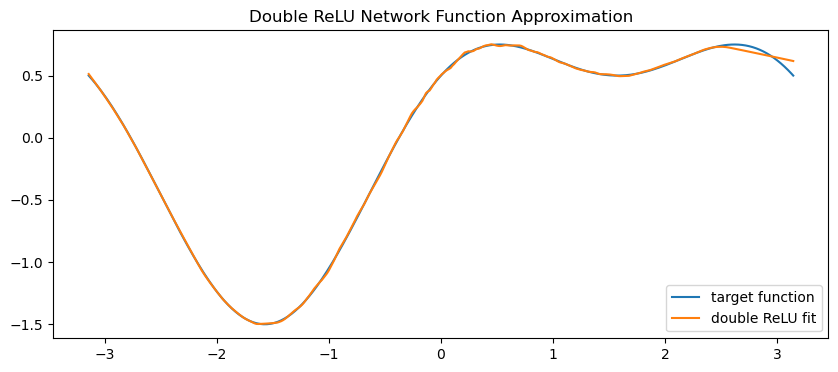

In [3]:
import matplotlib.pyplot as plt

# 在闭区间 [-pi, pi] 上选择一个有界函数作为示例
# 理论上双层 ReLU 网络可以逼近任意连续有界函数
x_fit = np.linspace(-np.pi, np.pi, 400).reshape(-1, 1)
y_fit = (np.sin(x_fit) + 0.5 * np.cos(2 * x_fit)).reshape(-1, 1)

fit_model = DoubleReluNet(hidden1=1024, hidden2=1024)  # 可以调整隐藏层的大小来观察拟合效果(一般越大越好)
lr = 1e-3
epochs = 5000

for epoch in range(epochs):
    pred = fit_model.forward(x_fit)
    loss = mse_loss(pred, y_fit)
    fit_model.backward(y_fit)
    fit_model.step(lr)

    if epoch % 500 == 0:
        print('epoch', epoch, 'mse loss', loss)

pred = fit_model.forward(x_fit)
print('final mse loss', mse_loss(pred, y_fit))

plt.figure(figsize=(10, 4))
plt.plot(x_fit, y_fit, label='target function')
plt.plot(x_fit, pred, label='double ReLU fit')
plt.legend()
plt.title('Double ReLU Network Function Approximation')
plt.show()